# **프로젝트: 트랜스포머로 만드는 대화형 챗봇**

#### **프로젝트 개요**  

**1. 프로젝트 목적:**  

트랜스포머(Transformer) 아키텍처를 직접 구현하고 한국어 대화 데이터를 학습시켜, 사용자의 감정에 공감하고 적절한 위로를 건네는 챗봇을 제작한다.  


**2. 데이터셋: 🤖 [한국어 챗봇 데이터](https://github.com/songys/Chatbot_data/tree/master?tab=readme-ov-file) (송영숙님 제공)**  

- 일상, 이별, 사랑 등 3가지 테마로 구성된 약 11,823개의 한국어 Q&A 쌍
- SentencePiece를 사용하여 한국어 특성에 맞는 서브워드(Subword) 토큰화 적용


**3. 모델:**  

멀티 헤드 어텐션(Multi-Head Attention) 기반의 트랜스포머를 경량화하여 설계했다.  

- 파라미터 수 약 878만 개, 2개의 인코더-디코더 레이어, 256차원의 임베딩 공간

<br><br/>

*본 실험 보고서는 2026/02/06 코드 리뷰 후 수정한 버전임

## 1. 라이브러리 불러오기 & 경로 설정

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler

import sentencepiece as spm

import pandas as pd
import numpy as np

import math
import os
import re
import random
import urllib.request
import zipfile
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

PyTorch version: 2.7.1+cu118
CUDA available: True


In [2]:
# 경로 설정
HOME_DIR = os.path.join(os.getenv("HOME"), 'work/transformer_chatbot/')
DATA_DIR = HOME_DIR + 'data/ChatbotData.csv'

## 2. 데이터 전처리

### 챗봇 데이터 기본 정보 확인

In [3]:
train_data = pd.read_csv(DATA_DIR)
pd.set_option('display.max_colwidth', 500) # 열 디스플레이 옵션 설정
print(train_data.shape)

(11823, 3)


In [4]:
train_data.head()

,Q,A,label
0,12시 땡!,하루가 또 가네요.,0
1,1지망 학교 떨어졌어,위로해 드립니다.,0
2,3박4일 놀러가고 싶다,여행은 언제나 좋죠.,0
3,3박4일 정도 놀러가고 싶다,여행은 언제나 좋죠.,0
4,PPL 심하네,눈살이 찌푸려지죠.,0


In [5]:
train_data.tail()

,Q,A,label
11818,훔쳐보는 것도 눈치 보임.,티가 나니까 눈치가 보이는 거죠!,2
11819,훔쳐보는 것도 눈치 보임.,훔쳐보는 거 티나나봐요.,2
11820,흑기사 해주는 짝남.,설렜겠어요.,2
11821,힘든 연애 좋은 연애라는게 무슨 차이일까?,잘 헤어질 수 있는 사이 여부인 거 같아요.,2
11822,힘들어서 결혼할까봐,도피성 결혼은 하지 않길 바라요.,2


In [6]:
# 결측치 확인
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11823 entries, 0 to 11822
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Q       11823 non-null  object
 1   A       11823 non-null  object
 2   label   11823 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 277.2+ KB


In [7]:
# 중복 확인
print(train_data.duplicated().sum())

0


### 데이터 증강

In [8]:
def augment_text(text):
    words = str(text).split() 
    
    if len(words) < 2:
        return text

    method = random.choice(['delete', 'swap', 'keep'])

    if method == 'delete': # 무작위 삭제 (random deletion)
        idx = random.randint(0, len(words) - 1)
        words.pop(idx)
    elif method == 'swap': # 무작위 교체 (random swap)
        idx1, idx2 = random.sample(range(len(words)), 2)
        words[idx1], words[idx2] = words[idx2], words[idx1]

    return " ".join(words) # keep 일 때는 아무 작업도 안함

In [9]:
augmented_list = []

for i, row in train_data.iterrows():
    original_q = row['Q'] # 원본 질문과 답변 가져오기
    original_a = row['A']

    aug_q = augment_text(original_q) # 질문만 증강
    augmented_list.append({'Q': aug_q, 'A': original_a})

    aug_a = augment_text(original_a) # 답변만 증강
    augmented_list.append({'Q': original_q, 'A': aug_a})

In [10]:
augmented_list[12000:12010]

[{'Q': '눈물이', 'A': '눈물 더 흘려도 돼요.'},
 {'Q': '눈물이 많터냐', 'A': '눈물 더 흘려도 돼요.'},
 {'Q': '눈물이 감정이안나오네 슬퍼도 말랐는지', 'A': '참지 마세요.'},
 {'Q': '눈물이 말랐는지 슬퍼도 감정이안나오네', 'A': '참지 마세요.'},
 {'Q': '멈춰지질 눈물이 않네', 'A': '지금은 우세요.'},
 {'Q': '눈물이 멈춰지질 않네', 'A': '우세요. 지금은'},
 {'Q': '문신 어때?', 'A': '화장하는 시간이 줄어들 거예요.'},
 {'Q': '눈썹 문신 어때?', 'A': '화장하는 줄어들 시간이 거예요.'},
 {'Q': '뉴스는 역시 지루해', 'A': '흥미를 가져보세요.'},
 {'Q': '뉴스는 역시 지루해', 'A': '흥미를 가져보세요.'}]

In [11]:
train_data = pd.concat([train_data, pd.DataFrame(augmented_list)], 
                       ignore_index=True) # 증강된 데이터 합치기
train_data = train_data.sample(frac=1, random_state=42).reset_index(drop=True) # 데이터 섞기

In [12]:
print(train_data.shape) # 원본 데이터 + 질문 증강 데이터 + 답변 증강 데이터

(35469, 3)


### 전처리 함수 정의

In [13]:
def preprocess_sentence(sentence):
    """
    한국어 텍스트 전처리 함수
    - 특수문자 정규화
    - 중복 공백 제거
    - 불필요한 기호 정리
    """
    if not isinstance(sentence, str):
        return ""
    
    # 연속된 구두점 정규화
    sentence = re.sub(r'([!?.]){2,}', r'\1', sentence)
    
    # 한글, 영어, 숫자, 주요 문장부호를 제외한 모든 문자 제거
    sentence = re.sub(r"[^가-힣a-zA-Z0-9?.!,]+", " ", sentence)
    
    # 중복 공백 제거
    sentence = re.sub(r'\s+', ' ', sentence)
    
    # 앞뒤 공백 제거
    sentence = sentence.strip()
    
    return sentence

In [14]:
def prepare_chatbot_data(df):
    """
    Pandas 데이터프레임(df)에서 질문(Q)과 답변(A) 쌍을 추출하여 전처리
    """
    questions = []
    answers = []
    
    # 데이터프레임의 행을 하나씩 순회하며 Q와 A 컬럼 값을 가져오기 
    for i in range(len(df)):
        # preprocess_sentence 함수를 적용하여 정제
        question = preprocess_sentence(df['Q'].iloc[i])
        answer = preprocess_sentence(df['A'].iloc[i])
        
        # 정제 후 빈 문장이 아닌 경우에만 리스트에 추가
        if len(question) > 0 and len(answer) > 0:
            questions.append(question)
            answers.append(answer)
    
    return questions, answers

### 데이터 전처리 실행

In [15]:
questions, answers = prepare_chatbot_data(train_data)

print(f"전처리 완료: {len(questions)}개의 질문-답변 쌍")
print(f"\n예시 (처음 3개):")

# 리스트의 첫 3개 출력
for i in range(min(3, len(questions))):
    print(f"Q: {questions[i]}")
    print(f"A: {answers[i]}")
    print()

전처리 완료: 35469개의 질문-답변 쌍

예시 (처음 3개):
Q: 치맥먹으면서 축구봐야지
A: 보다보면 재미있어요.

Q: 남자친구가 친구들이랑 여행을 여자도 있으면 어떡해?
A: 같이 갈 수 있으면 같이 가요.

Q: 즐겨야지 축제날은
A: 즐길 수 있을 때 즐기세요.



## 3. SentencePiece 토크나이저 학습

In [16]:
# 코퍼스 파일 준비
corpus_path = 'chatbot_corpus.txt'

# 리스트 개수가 일치하는지 확인 (디버깅용)
if len(questions) == len(answers):
    with open(corpus_path, 'w', encoding='utf-8') as f:
        for question, answer in zip(questions, answers):
            f.write(question + '\n')
            f.write(answer + '\n')
    print(f"총 {len(questions) * 2}개의 문장이 {corpus_path}에 저장되었습니다.")
else:
    print("경고: 질문과 답변의 개수가 일치하지 않습니다.")

# 파일 생성 확인
if os.path.exists(corpus_path):
    print("토크나이저 학습을 위한 코퍼스 파일이 생성되었습니다.")

총 70938개의 문장이 chatbot_corpus.txt에 저장되었습니다.
토크나이저 학습을 위한 코퍼스 파일이 생성되었습니다.


In [17]:
# SentencePiece 모델 학습
vocab_size = 8000
model_prefix = 'korean_chatbot_sp'

spm.SentencePieceTrainer.train(
    input=corpus_path,
    model_prefix=model_prefix,
    vocab_size=vocab_size,
    model_type='bpe',          # 혹은 더 유연한 'unigram' 추천
    character_coverage=1.0,    # 한국어 전체를 커버하려면 1.0 추천
    pad_id=0,                  # <pad> 토큰
    bos_id=1,                  # <s> 토큰 (Start of Sequence)
    eos_id=2,                  # </s> 토큰 (End of Sequence)
    unk_id=3                   # <unk> 토큰
    # 별도의 user_defined_symbols를 넣지 않아도 위 ID 설정으로 기본 토큰이 생성
)

# SentencePiece 모델 로드
sp = spm.SentencePieceProcessor()
sp.load(f'{model_prefix}.model')

print(f"SentencePiece 모델 학습 완료")
print(f"어휘 크기: {sp.get_piece_size()}") # vocab_size()보다 get_piece_size()가 더 정확

# 토큰화 테스트
test_sentence = questions[0]
print(f"\n원문: {test_sentence}")
print(f"토큰(Pieces): {sp.encode_as_pieces(test_sentence)}")
print(f"정수(IDs): {sp.encode_as_ids(test_sentence)}")

SentencePiece 모델 학습 완료
어휘 크기: 8000

원문: 치맥먹으면서 축구봐야지
토큰(Pieces): ['▁치맥', '먹', '으면서', '▁축구', '봐야지']
정수(IDs): [4119, 6895, 1954, 2448, 4611]


sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: chatbot_corpus.txt
  input_format: 
  model_prefix: korean_chatbot_sp
  model_type: BPE
  vocab_size: 8000
  self_test_sample_size: 0
  character_coverage: 1
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 3
  bos_id: 1
  eos_id: 2
  pad_id: 0
  unk_piece: <unk>
  bos_piece: <s>
  eos_piece: </s>
  pad_piece: <pad>
  unk_surface:  ⁇ 
  enable_differential_privacy: 0
  

## 4. 데이터셋 클래스 생성

In [18]:
class ChatbotDataset(Dataset):
    def __init__(self, questions, answers, sp, max_len=64):
        self.questions = questions
        self.answers = answers
        self.sp = sp
        self.max_len = max_len
        
        # SentencePiece의 특수 토큰 ID 설정
        self.SOS_token = sp.bos_id() # <sos> 또는 <s>
        self.EOS_token = sp.eos_id() # <eos> 또는 </s>
        self.PAD_token = sp.pad_id() # <pad>
    
    def __len__(self):
        return len(self.questions)
    
    def __getitem__(self, idx):
        question = self.questions[idx]
        answer = self.answers[idx]
        
        # 인코더 입력 (Source): [SOS] + 질문 + [EOS]
        # 모델의 인코더가 질문의 시작과 끝을 알 수 있도록 함
        src = [self.SOS_token] + self.sp.encode_as_ids(question) + [self.EOS_token]
        
        # 디코더 입력 (Target Input): [SOS] + 답변
        # Teacher Forcing을 위해 정답 문장을 입력으로 사용
        trg_input = [self.SOS_token] + self.sp.encode_as_ids(answer)
        
        # 디코더 타겟 (Target Output): 답변 + [EOS]
        # 모델이 예측해야 하는 실제 목표값
        trg_output = self.sp.encode_as_ids(answer) + [self.EOS_token]
        
        # 패딩 처리 (모두 동일한 max_len으로 맞춤)
        src = self._pad_sequence(src)
        trg_input = self._pad_sequence(trg_input)
        trg_output = self._pad_sequence(trg_output)
        
        # PyTorch 모델 입력 형식에 맞게 텐서로 변환하여 반환
        return {
            'src': torch.tensor(src, dtype=torch.long),
            'trg_input': torch.tensor(trg_input, dtype=torch.long),
            'trg_output': torch.tensor(trg_output, dtype=torch.long)
        }
    
    def _pad_sequence(self, seq):
        if len(seq) < self.max_len:
            seq = seq + [self.PAD_token] * (self.max_len - len(seq))
        else:
            seq = seq[:self.max_len]
        return seq

In [19]:
# 훈련/검증 데이터 분할
split_idx = int(len(questions) * 0.9)
train_questions = questions[:split_idx]
train_answers = answers[:split_idx]
val_questions = questions[split_idx:]
val_answers = answers[split_idx:]

In [20]:
# 데이터셋 생성
max_seq_len = 64
train_dataset = ChatbotDataset(train_questions, train_answers, sp, max_seq_len)
val_dataset = ChatbotDataset(val_questions, val_answers, sp, max_seq_len)

print(f"학습 데이터: {len(train_dataset)}")
print(f"검증 데이터: {len(val_dataset)}")

학습 데이터: 31922
검증 데이터: 3547


## 5. 트랜스포머 모델 구성

In [21]:
class PositionalEncoding(nn.Module):
    def __init__(self, position, d_model):
        super(PositionalEncoding, self).__init__()
        self.d_model = d_model
        self.position = position

        self.pos_encoding = self._build_pos_encoding(position, d_model)

    def _get_angles(self, position, i, d_model):
        return 1.0 / (10000.0 ** ((2.0 * (i // 2)) / d_model)) * position

    def _build_pos_encoding(self, position, d_model):
        pos = torch.arange(position, dtype=torch.float32).unsqueeze(1)
        i = torch.arange(d_model, dtype=torch.float32).unsqueeze(0)

        angle_rads = self._get_angles(pos, i, d_model)
        sines = torch.sin(angle_rads[:, 0::2])
        cosines = torch.cos(angle_rads[:, 1::2])

        pos_encoding = torch.zeros(position, d_model)
        pos_encoding[:, 0::2] = sines
        pos_encoding[:, 1::2] = cosines

        pos_encoding = pos_encoding.unsqueeze(0)  # shape: [1, position, d_model]
        return pos_encoding

    def forward(self, x):
        return x + self.pos_encoding[:, :x.size(1), :].to(x.device)

In [22]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        self.d_model = d_model
        self.num_heads = num_heads
        
        assert d_model % num_heads == 0
        
        self.depth = d_model // num_heads
        
        self.wq = nn.Linear(d_model, d_model)
        self.wk = nn.Linear(d_model, d_model)
        self.wv = nn.Linear(d_model, d_model)
        
        self.dense = nn.Linear(d_model, d_model)
    
    def split_heads(self, x, batch_size):
        x = x.view(batch_size, -1, self.num_heads, self.depth)
        return x.permute(0, 2, 1, 3)
    
    def scaled_dot_product_attention(self, q, k, v, mask):
        matmul_qk = torch.matmul(q, k.transpose(-2, -1)) # 두 차원을 서로 교차
        
        # math.sqrt를 사용하여 CPU/GPU 동기화 병목 방지
        dk = k.size(-1)
        scaled_attention_logits = matmul_qk / math.sqrt(dk)
        
        if mask is not None:
            # In-place 연산 피하기
            scaled_attention_logits = scaled_attention_logits + (mask * -1e9)
        
        attention_weights = F.softmax(scaled_attention_logits, dim=-1)
        output = torch.matmul(attention_weights, v)
        
        return output, attention_weights
    
    def forward(self, q, k, v, mask):
        batch_size = q.size(0)
        
        q = self.wq(q)
        k = self.wk(k)
        v = self.wv(v)
        
        q = self.split_heads(q, batch_size)
        k = self.split_heads(k, batch_size)
        v = self.split_heads(v, batch_size)
        
        scaled_attention, attention_weights = self.scaled_dot_product_attention(q, k, v, mask)

        # (batch_size, num_heads, seq_len, depth) -> (batch_size, seq_len, num_heads, depth)
        scaled_attention = scaled_attention.permute(0, 2, 1, 3)
        
        # 다시 (batch_size, seq_len, d_model)로 합치기
        concat_attention = scaled_attention.contiguous().view(batch_size, -1, self.d_model)
        
        output = self.dense(concat_attention)
        
        return output, attention_weights

In [23]:
class PointWiseFeedForwardNetwork(nn.Module):
    def __init__(self, d_model, dff):
        super(PointWiseFeedForwardNetwork, self).__init__()
        self.dense1 = nn.Linear(d_model, dff)
        self.dense2 = nn.Linear(dff, d_model)
    
    def forward(self, x):
        x = self.dense1(x)
        x = F.relu(x)
        x = self.dense2(x)
        return x

In [24]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, dff, dropout_rate=0.1):
        super(EncoderLayer, self).__init__()
        
        self.mha = MultiHeadAttention(d_model, num_heads)
        self.ffn = PointWiseFeedForwardNetwork(d_model, dff)
        
        self.layernorm1 = nn.LayerNorm(d_model, eps=1e-6)
        self.layernorm2 = nn.LayerNorm(d_model, eps=1e-6)
        
        self.dropout1 = nn.Dropout(dropout_rate)
        self.dropout2 = nn.Dropout(dropout_rate)
    
    def forward(self, x, mask):
        attn_output, _ = self.mha(x, x, x, mask) # q, k, v 순서
        attn_output = self.dropout1(attn_output)
        out1 = self.layernorm1(x + attn_output)
        
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output)
        out2 = self.layernorm2(out1 + ffn_output)
        
        return out2

In [25]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, dff, dropout_rate=0.1):
        super(DecoderLayer, self).__init__()
        
        self.mha1 = MultiHeadAttention(d_model, num_heads)
        self.mha2 = MultiHeadAttention(d_model, num_heads)
        self.ffn = PointWiseFeedForwardNetwork(d_model, dff)
        
        self.layernorm1 = nn.LayerNorm(d_model, eps=1e-6) # 분모가 0이 되는 것을 방지하는 안전 장치
        self.layernorm2 = nn.LayerNorm(d_model, eps=1e-6)
        self.layernorm3 = nn.LayerNorm(d_model, eps=1e-6)
        
        self.dropout1 = nn.Dropout(dropout_rate)
        self.dropout2 = nn.Dropout(dropout_rate)
        self.dropout3 = nn.Dropout(dropout_rate)
    
    def forward(self, x, enc_output, look_ahead_mask, padding_mask):
        # mha1: Masked Self-Attention (디코더가 생성한 단어들끼리 (x) 비교)
        attn1, attn_weights_block1 = self.mha1(x, x, x, look_ahead_mask) # 미래 시점의 단어를 가림
        attn1 = self.dropout1(attn1)
        out1 = self.layernorm1(attn1 + x) # 잔차 연결 + 레이어 정규화

        # mha2: Encoder-Decoder Attention (디코더의 질문(out1)으로 인코더의 정보(enc_output)를 찾음)
        # 순서: q, k, v
        # q == out1
        # k, v == enc_output
        attn2, attn_weights_block2 = self.mha2(out1, enc_output, enc_output, padding_mask) # 인코더의 패딩을 무시
        attn2 = self.dropout2(attn2)
        out2 = self.layernorm2(attn2 + out1) # 잔차 연결 + 레이어 정규화
        
        ffn_output = self.ffn(out2)
        ffn_output = self.dropout3(ffn_output)
        out3 = self.layernorm3(ffn_output + out2) # 잔차 연결 + 레이어 정규화
        
        return out3, attn_weights_block1, attn_weights_block2

In [26]:
class Encoder(nn.Module):
    """인코더 층을 여러 개 쌓아올린 인코더 모듈"""
    def __init__(self, num_layers, d_model, num_heads, dff, input_vocab_size, maximum_position_encoding, dropout_rate=0.1):
        super(Encoder, self).__init__()
        
        self.d_model = d_model
        self.num_layers = num_layers
        
        self.embedding = nn.Embedding(input_vocab_size, d_model)
        self.pos_encoding = PositionalEncoding(maximum_position_encoding, d_model)
        
        self.enc_layers = nn.ModuleList([EncoderLayer(d_model, num_heads, dff, dropout_rate) 
                                         for _ in range(num_layers)])
        
        self.dropout = nn.Dropout(dropout_rate)
    
    def forward(self, x, mask):
        # 임베딩 레이어 통과
        x = self.embedding(x) # (batch_size, input_seq_len, d_model)
        
        # 임베딩 스케일링 (상수로 계산하는 것이 효율적)
        x = x * math.sqrt(self.d_model)
        
        # 위치 인코딩 추가
        x = self.pos_encoding(x)
        
        # 드롭아웃
        x = self.dropout(x)
        
        # 인코더 레이어 반복 통과 (N층 쌓기)
        for i in range(self.num_layers):
            x = self.enc_layers[i](x, mask)
        
        return x # (batch_size, input_seq_len, d_model)

In [27]:
class Decoder(nn.Module):
    """디코더 층을 여러 개 쌓아올린 디코더 모듈"""
    def __init__(self, num_layers, d_model, num_heads, dff, target_vocab_size, maximum_position_encoding, dropout_rate=0.1):
        super(Decoder, self).__init__()
        
        self.d_model = d_model
        self.num_layers = num_layers
        
        self.embedding = nn.Embedding(target_vocab_size, d_model)
        self.pos_encoding = PositionalEncoding(maximum_position_encoding, d_model)
        
        self.dec_layers = nn.ModuleList([DecoderLayer(d_model, num_heads, dff, dropout_rate) 
                                         for _ in range(num_layers)])
        
        self.dropout = nn.Dropout(dropout_rate)
    
    def forward(self, x, enc_output, look_ahead_mask, padding_mask):
            attention_weights = {}
            
            # 타겟 임베딩 및 스케일링
            x = self.embedding(x) 
        
            # 인코더와 동일하게 math.sqrt 사용
            x = x * math.sqrt(self.d_model)
            
            # 위치 인코딩 및 드롭아웃
            x = self.pos_encoding(x)
            x = self.dropout(x)
            
            # 디코더 레이어 N층 통과
            for i in range(self.num_layers):
                # x: 출력 벡터, block1: Self-Attention 가중치, block2: Cross-Attention 가중치
                x, block1, block2 = self.dec_layers[i](x, enc_output, look_ahead_mask, padding_mask)
                
                # 레이어별 가중치 저장
                attention_weights[f'decoder_layer{i+1}_block1'] = block1
                attention_weights[f'decoder_layer{i+1}_block2'] = block2
            
            # x의 shape: (batch_size, target_seq_len, d_model)
            return x, attention_weights

In [28]:
class Transformer(nn.Module):
    def __init__(self, num_layers, d_model, num_heads, dff, input_vocab_size, 
                 target_vocab_size, pe_input, pe_target, dropout_rate=0.1):
        super(Transformer, self).__init__()
        
        # 인코더 정의
        self.encoder = Encoder(num_layers, d_model, num_heads, dff, 
                               input_vocab_size, pe_input, dropout_rate)
        
        # 디코더 정의
        self.decoder = Decoder(num_layers, d_model, num_heads, dff, 
                               target_vocab_size, pe_target, dropout_rate)
        
        # 최종 출력 선형 레이어 (벡터 -> 단어별 점수)
        self.final_layer = nn.Linear(d_model, target_vocab_size)
    
    def forward(self, inp, tar, enc_padding_mask, look_ahead_mask, dec_padding_mask):
        # 인코더 통과
        enc_output = self.encoder(inp, enc_padding_mask) # (batch_size, inp_seq_len, d_model)
        
        # 디코더 통과 (인코더 출력값 enc_output을 전달!)
        dec_output, attention_weights = self.decoder(
            tar, enc_output, look_ahead_mask, dec_padding_mask)
        
        # 최종 단어 예측
        final_output = self.final_layer(dec_output) # (batch_size, tar_seq_len, target_vocab_size)
        
        return final_output, attention_weights

## 6. 마스크 생성 함수 정의

In [29]:
def create_padding_mask(seq, pad_token=0):
    """
    패딩 마스크 생성
    """
    mask = (seq == pad_token).float()
    return mask.unsqueeze(1).unsqueeze(2)

In [30]:
def create_look_ahead_mask(size, device):
    """
    Look-ahead 마스크 생성 (디코더용)
    """
    # 미래 시점의 단어를 가리기 위해 1로 채워진 상삼각 행렬을 생성
    mask = torch.triu(torch.ones((size, size), device=device), diagonal=1)
    return mask

In [31]:
def create_masks(inp, tar, pad_token=0):
    """
    모든 마스크 생성
    """
    device = inp.device
    
    # 인코더 패딩 마스크
    enc_padding_mask = create_padding_mask(inp, pad_token)
    
    # 디코더의 두 번째 어텐션 블록용 패딩 마스크 (인코더 출력 가리기)
    dec_padding_mask = create_padding_mask(inp, pad_token)
    
    # 디코더의 첫 번째 어텐션 블록용 마스크 (미래 단어 가리기 + 타겟 패딩 가리기)
    look_ahead_mask = create_look_ahead_mask(tar.size(1), device)
    dec_target_padding_mask = create_padding_mask(tar, pad_token).to(device)
    
    # 두 마스크를 합쳐서 1인 곳은 모두 가림 -> torch.maximum 사용 이유 
    combined_mask = torch.maximum(dec_target_padding_mask, look_ahead_mask)
    
    return enc_padding_mask, combined_mask, dec_padding_mask

## 7. 모델 학습 함수 정의

In [32]:
def accuracy_function(predictions, targets, pad_id=0):
    """
    predictions: (batch_size, seq_len, vocab_size) - 모델의 출력(Logits)
    targets: (batch_size, seq_len) - 실제 정답 토큰(Label)
    """
    # 마지막 차원(vocab_size)에서 가장 높은 확률의 인덱스를 추출
    preds = predictions.argmax(dim=-1)  
    
    # 패딩 토큰을 제외한 마스크 생성
    mask = (targets != pad_id)
    
    # 정답과 일치하면서 패딩이 아닌 것만 계산
    correct = (preds == targets) & mask
    
    # 정확도 계산: (맞은 개수) / (패딩 제외 전체 개수)
    acc = correct.float().sum() / mask.float().sum()
    return acc

In [33]:
# Custom learning rate scheduling 정의
def get_lr_lambda(d_model, warmup_steps=4000):
    d_model = float(d_model)
    def lr_lambda(step):
        # step은 0부터 시작하므로 +1로 보정
        step = step + 1
        return (d_model ** -0.5) * min(step ** -0.5, step * (warmup_steps ** -1.5))
    return lr_lambda

In [34]:
def train_epoch(model, dataloader, criterion, optimizer, device, pad_token):
    """모델 학습 함수"""
    model.train()
    total_loss = 0
    total_acc = 0
    
    progress_bar = tqdm(dataloader, desc='Training')
    
    for batch in progress_bar:
        # 데이터 장치 이동
        encoder_input = batch['src'].to(device)
        decoder_input = batch['trg_input'].to(device)
        decoder_target = batch['trg_output'].to(device) # 이것이 바로 targets!
        
        # 마스크 생성
        enc_padding_mask, look_ahead_mask, dec_padding_mask = create_masks(
            encoder_input, decoder_input, pad_token
        )
        
        optimizer.zero_grad()
        
        # 순전파 (Forward)
        # predictions shape: (batch_size, seq_len, vocab_size)
        predictions, _ = model(
            encoder_input, 
            decoder_input, 
            enc_padding_mask, 
            look_ahead_mask, 
            dec_padding_mask
        )
        
        # 손실 계산 (view를 통해 차원을 펼쳐서 계산)
        # predictions shape: (batch_size, seq_len, vocab_size) -> (-1, vocab_size)
        # decoder_target shape: (batch_size, seq_len) -> (-1)
        # target_vocab_size 대신 predictions.size(-1)을 써서 유연하게 대처
        loss = criterion(predictions.view(-1, predictions.size(-1)), 
                         decoder_target.view(-1))
        
        # step 계산
        current_step = progress_bar.n + 1
        
        # 정확도 계산 (우리가 이름을 바꾼 그 함수!)
        acc = accuracy_function(predictions, decoder_target, pad_id=pad_token)
        
        # 역전파 및 가중치 업데이트
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0) # 기울기 폭주 방지 (gradient clipping)
        optimizer.step()
        scheduler.step() # 배치당 스케줄러 1회 업데이트
        
        total_loss += loss.item()
        total_acc += acc.item()
        
        # 실시간 상태 표시
        progress_bar.set_postfix({
            'step': f"{current_step}/{len(dataloader)}",
            'loss': f"{loss.item():.4f}",
            'acc': f"{acc.item():.4f}"
        })
    
    return total_loss / len(dataloader), total_acc / len(dataloader)

In [35]:
def validate_epoch(model, dataloader, criterion, device, pad_token):
    """모델 검증 함수 (정확도 계산 포함)"""
    model.eval() # 평가 모드 전환
    total_loss = 0
    total_acc = 0
    
    with torch.no_grad(): # 기울기 계산 비활성화
        for batch in tqdm(dataloader, desc='Validation'):
            encoder_input = batch['src'].to(device)
            decoder_input = batch['trg_input'].to(device)
            decoder_target = batch['trg_output'].to(device)

            # 마스크 생성
            enc_padding_mask, look_ahead_mask, dec_padding_mask = create_masks(
                encoder_input, decoder_input, pad_token
            )

            # 순전파
            predictions, _ = model(
                encoder_input, 
                decoder_input, 
                enc_padding_mask, 
                look_ahead_mask, 
                dec_padding_mask
            )

            # 손실 계산 (predictions.size(-1) 사용 권장)
            loss = criterion(predictions.view(-1, predictions.size(-1)), 
                             decoder_target.view(-1))
            
            acc = accuracy_function(predictions, decoder_target, pad_id=pad_token)
            
            total_loss += loss.item()
            total_acc += acc.item()
            
    return total_loss / len(dataloader), total_acc / len(dataloader)

In [36]:
def predict_answer(model, question, sp, device, max_len=64, temperature=0.8):
    """온도 조절 샘플링이 적용된 모델 예측 함수"""
    model.eval() # 평가 모드 전환

    # 토큰 정의
    SOS_token = sp.bos_id()
    EOS_token = sp.eos_id()
    PAD_token = sp.pad_id()
    
    # 인코더 입력 준비
    question = preprocess_sentence(question)
    enc_input_ids = [SOS_token] + sp.encode_as_ids(question) + [EOS_token]
    
    # 인코더 입력은 고정 길이로 패딩 처리
    if len(enc_input_ids) < max_len:
        enc_input_ids += [PAD_token] * (max_len - len(enc_input_ids))
    else:
        enc_input_ids = enc_input_ids[:max_len]
    
    encoder_input = torch.tensor([enc_input_ids], dtype=torch.long).to(device)
    
    # 디코더 입력 시작 (SOS로 시작)
    decoder_input_list = [SOS_token]
    
    with torch.no_grad():
        for i in range(max_len):
            # 현재까지의 단어들만 텐서로 변환 (패딩 없이 진행)
            decoder_input = torch.tensor([decoder_input_list], dtype=torch.long).to(device)
            
            # 마스크 생성 (현재 decoder_input 길이에 맞춰서 생성)
            enc_padding_mask, look_ahead_mask, dec_padding_mask = create_masks(
                encoder_input, decoder_input, PAD_token
            )
            
            # 예측
            predictions, _ = model(
                encoder_input,
                decoder_input,
                enc_padding_mask,
                look_ahead_mask,
                dec_padding_mask
            )

            # 온도 조절 및 샘플링 적용 
            logits = predictions[0, -1, :] # 마지막 타임스텝의 예측값 추출: (vocab_size,)

            # 온도를 나누어 분포를 조절 (T가 낮으면 정답에 집중, T가 높으면 다양성 증가)
            logits = logits / temperature

            # 소프트맥스를 통해 확률 분포 생성
            probabilities = torch.softmax(logits, dim=-1)

            # argmax 대신 확률 분포에 따른 샘플링 수행
            predicted_id = torch.multinomial(probabilities, num_samples=1).item()
            
            # 종료 토큰이 나오면 멈춤
            if predicted_id == EOS_token:
                break
            
            # 예측된 단어를 다음 입력 리스트에 추가
            decoder_input_list.append(predicted_id)
            
    # SOS 토큰 제외하고 디코딩 (문장 복원)
    answer = sp.decode_ids(decoder_input_list[1:])
    return answer

In [37]:
def set_seed(seed=42):
    # 파이썬 난수 고정
    random.seed(seed)
    # 환경 변수 고정 (해시 시드)
    os.environ['PYTHONHASHSEED'] = str(seed)
    # 넘파이 난수 고정
    np.random.seed(seed)
    # 파이토치 CPU 및 GPU 난수 고정
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) 
    
    # CuDNN 연산 설정
    torch.backends.cudnn.deterministic = True # True: 동일한 입력에 대해 항상 동일한 연산 결과가 나오도록 고정 (재현성 보장)
    torch.backends.cudnn.benchmark = False # False: 하드웨어에 최적화된 가장 빠른 알고리즘을 찾는 기능을 끔
                                            # 알고리즘이 바뀌면 미세한 오차가 발생하여 재현성이 깨질 수 있기 때문

## 8. 모델 학습

In [38]:
set_seed(42) # 시드 고정

In [39]:
# 하이퍼파라미터 설정

# 모델 구조 관련
num_layers = 2
d_model = 256
dff = 512
num_heads = 8
dropout_rate = 0.2 # 과적합 방지

# 데이터 및 임베딩 파라미터
input_vocab_size = sp.vocab_size()
target_vocab_size = sp.vocab_size()
max_position_encoding = max_seq_len

# 학습 및 추론 관련
epochs = 100
batch_size = 128
learning_rate = 1.0 # custom scheduling 사용하므로
warmup_steps = 4000
inference_temp = 0.3
early_stop_patience = 30

print(f"모델 파라미터:")
print(f"  레이어 수: {num_layers}")
print(f"  모델 차원: {d_model}")
print(f"  FFN 차원: {dff}")
print(f"  어텐션 헤드: {num_heads}")
print(f"  배치 크기: {batch_size}")
print(f"  에폭: {epochs}")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"사용 디바이스: {device}")

모델 파라미터:
  레이어 수: 2
  모델 차원: 256
  FFN 차원: 512
  어텐션 헤드: 8
  배치 크기: 128
  에폭: 100
사용 디바이스: cuda


In [40]:
# 데이터로더 생성
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

print(f"학습 배치 수: {len(train_loader)}")
print(f"검증 배치 수: {len(val_loader)}")

학습 배치 수: 250
검증 배치 수: 28


In [41]:
# 인코딩 확인
# 단일 배치 가져오기
sample_batch = next(iter(train_loader))

# 딕셔너리 형태인 경우 키(Key) 목록 추출
if isinstance(sample_batch, dict):
    keys = list(sample_batch.keys())
    batch_size_dim = len(sample_batch[keys[0]])
    
    for i in range(min(3, batch_size_dim)):
        print(f"\n[Sample {i+1}]")
        for key in keys:
            data = sample_batch[key][i]
            
            if torch.is_tensor(data):
                indices = data.tolist()
                clean_indices = [idx for idx in indices if idx != sp.pad_id()]
                print(f"{key} (인코딩): {clean_indices}")
                try:
                    print(f"{key} (복원)  : {sp.decode_ids(clean_indices)}")
                except: pass
            else:
                print(f"{key} (데이터): {data}")

# 리스트/튜플 형태인 경우
else:
    for i in range(min(3, len(sample_batch[0]))):
        print(f"\n[Sample {i+1}]")
        for idx, item in enumerate(sample_batch):
            data = item[i]
            if torch.is_tensor(data):
                indices = data.tolist()
                clean_indices = [idx_val for idx_val in indices if idx_val != sp.pad_id()]
                print(f"요소 {idx} (인코딩): {clean_indices}")
                try:
                    print(f"요소 {idx} (복원)  : {sp.decode_ids(clean_indices)}")
                except: pass
            else:
                print(f"요소 {idx} (데이터): {data}")


[Sample 1]
src (인코딩): [1, 125, 752, 2]
src (복원)  : 후 만남
trg_input (인코딩): [1, 791, 121, 1730, 62, 897, 980, 21, 6771]
trg_input (복원)  : 재회하면 머리가 더 복잡해질 거예요.
trg_output (인코딩): [791, 121, 1730, 62, 897, 980, 21, 6771, 2]
trg_output (복원)  : 재회하면 머리가 더 복잡해질 거예요.

[Sample 2]
src (인코딩): [1, 663, 3930, 6780, 2]
src (복원)  : 목 탄다
trg_input (인코딩): [1, 186, 374, 6771]
trg_input (복원)  : 물 드세요.
trg_output (인코딩): [186, 374, 6771, 2]
trg_output (복원)  : 물 드세요.

[Sample 3]
src (인코딩): [1, 1379, 4251, 2]
src (복원)  : 시험 지겨워
trg_input (인코딩): [1, 1268, 6679, 6771]
trg_input (복원)  : 나중에 없애주세요.
trg_output (인코딩): [1268, 6679, 6771, 2]
trg_output (복원)  : 나중에 없애주세요.


In [42]:
# 모델 초기화
model = Transformer(
    num_layers=num_layers,
    d_model=d_model,
    num_heads=num_heads,
    dff=dff,
    input_vocab_size=input_vocab_size,
    target_vocab_size=target_vocab_size,
    pe_input=max_position_encoding,
    pe_target=max_position_encoding,
    dropout_rate=dropout_rate
).to(device)

# 모델 파라미터 수 계산
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\n전체 파라미터: {total_params:,}")
print(f"학습 파라미터: {trainable_params:,}")


전체 파라미터: 8,787,776
학습 파라미터: 8,787,776


In [43]:
# 손실 함수 및 옵티마이저
criterion = nn.CrossEntropyLoss(ignore_index=sp.pad_id(),
                               label_smoothing=0.1) # target 값에 대해 100% 확신을 갖지 않게 하여 과적합 방지
optimizer = optim.Adam(model.parameters(), lr=learning_rate, betas=(0.9, 0.98), 
                       eps=1e-9, weight_decay=1e-5) # 가중치가 너무 커지는 것을 방지

# 학습률 스케줄러
scheduler = lr_scheduler.LambdaLR(optimizer, lr_lambda=get_lr_lambda(d_model, warmup_steps=warmup_steps))

In [44]:
# 학습 실행
patience_counter = 0 
best_val_loss = float('inf')

# 결과 저장을 위한 리스트 초기화
train_losses, val_losses, train_accs, val_accs = [], [], [], []

# 학습 과정 모니터링을 위한 테스트용 질문
test_questions = ["안녕?", "오늘 날씨 어때?", "이름이 뭐야?", "배고프다."]

for epoch in range(epochs):
    # 학습 및 검증 진행
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device, sp.pad_id())
    val_loss, val_acc = validate_epoch(model, val_loader, criterion, device, sp.pad_id())
    
    # loss, acc 기록 저장
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    
    # 현재 학습률 저장
    current_lr = optimizer.param_groups[0]['lr']
    
    # 성능이 가장 좋은 모델 저장 및 Early Stopping 체크
    if val_loss < best_val_loss: # 검증 손실(val_loss)이 최소가 될 때 가장 좋은 모델로 판단
        best_val_loss = val_loss
        patience_counter = 0  # 개선되었으므로 카운터 리셋
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'd_model': d_model,
            'num_layers': num_layers,
            'train_loss': train_loss,
            'val_loss': val_loss,
            'train_acc': train_acc,
            'val_acc': val_acc
        }, 'best_korean_chatbot_model.pt')
        status_msg = "★ Best Model Saved!"
    else:
        patience_counter += 1
        status_msg = f"patience: {patience_counter}/{early_stop_patience}"

    # 출력 제어: 1에폭, 마지막 에폭, 그리고 매 에폭(또는 5의 배수)마다 출력
    if (epoch + 1) == 1 or (epoch + 1) == epochs or (epoch + 1) % 1 == 0: # 매 에폭 확인을 위해 % 1로 수정
        print(f"\n{'='*20} Epoch {epoch+1}/{epochs} 결과 {'='*20}")
        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2%}")
        print(f"Val Loss: {val_loss:.4f}   | Val Acc: {val_acc:.2%}")
        print(f"LR: {current_lr:.6f} | {status_msg}")
        
        # 모델 추론 테스트
        print("\n[Model Test]")
        for q in test_questions:
            ans = predict_answer(model, q, sp, device, max_len=max_seq_len, temperature=inference_temp)
            print(f"Q: {q} -> A: {ans}")

        print("\n" + "="*52) # 에폭 구분

    # Early Stopping 발동
    if patience_counter >= early_stop_patience:
        print(f"\n{early_stop_patience}에폭 동안 개선이 없어 조기 종료합니다. (Best Val Loss: {best_val_loss:.4f})")
        break

print("\n" + "="*50)
print(f"학습 완료! 최종 Best Val Acc: {max(val_accs):.2%}")
print("="*50)

Training:   0%|          | 0/250 [00:00<?, ?it/s]

Validation:   0%|          | 0/28 [00:00<?, ?it/s]


==================== Epoch 1/100 결과 ====================
Train Loss: 7.6710 | Train Acc: 19.93%
Val Loss: 6.5112   | Val Acc: 28.50%
LR: 0.000062 | ★ Best Model Saved!

[Model Test]
Q: 안녕? -> A: 
Q: 오늘 날씨 어때? -> A: .
Q: 이름이 뭐야? -> A: .
Q: 배고프다. -> A: .



Training:   0%|          | 0/250 [00:00<?, ?it/s]

Validation:   0%|          | 0/28 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/28 [00:00<?, ?it/s]


==================== Epoch 99/100 결과 ====================
Train Loss: 1.4674 | Train Acc: 95.07%
Val Loss: 2.0217   | Val Acc: 89.14%
LR: 0.000397 | patience: 5/30

[Model Test]
Q: 안녕? -> A: 안녕하세요.
Q: 오늘 날씨 어때? -> A: 날씨 어플에 물어보세요.
Q: 이름이 뭐야? -> A: 위로봇이요.
Q: 배고프다. -> A: 저도 밥 먹고 싶어요



Training:   0%|          | 0/250 [00:00<?, ?it/s]

Validation:   0%|          | 0/28 [00:00<?, ?it/s]


==================== Epoch 100/100 결과 ====================
Train Loss: 1.4677 | Train Acc: 95.04%
Val Loss: 2.0211   | Val Acc: 89.24%
LR: 0.000395 | patience: 6/30

[Model Test]
Q: 안녕? -> A: 안녕하세요.
Q: 오늘 날씨 어때? -> A: 날씨 어플에 물어보세요.
Q: 이름이 뭐야? -> A: 위로봇이요.
Q: 배고프다. -> A: 저도 밥 먹고 싶어요


학습 완료! 최종 Best Val Acc: 89.46%


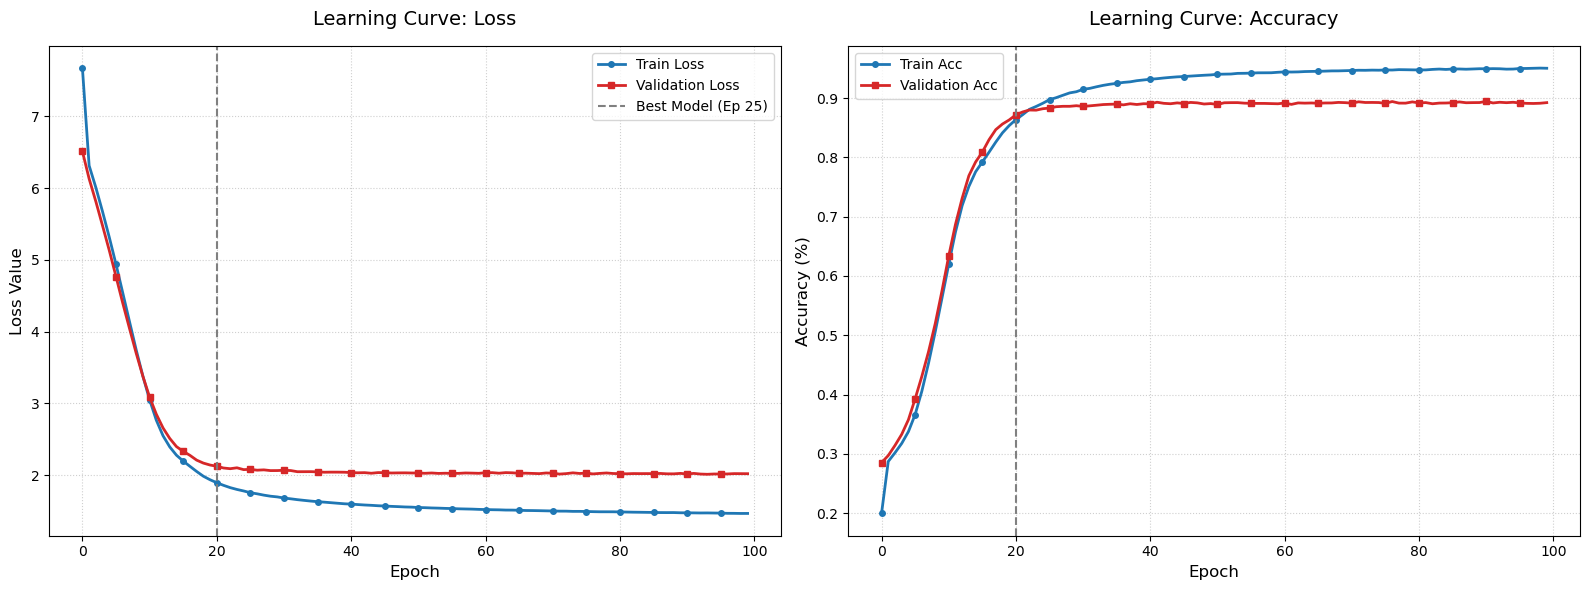

In [45]:
# 학습 곡선 시각화
plt.style.use('seaborn-v0_8-muted') # 그래프 스타일 설정
plt.figure(figsize=(16, 6))

# Loss 그래프 (왼쪽)
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', color='#1f77b4', linewidth=2, marker='o', markersize=4, markevery=5)
plt.plot(val_losses, label='Validation Loss', color='#d62728', linewidth=2, marker='s', markersize=4, markevery=5)
plt.axvline(x=20, color='gray', linestyle='--', label='Best Model (Ep 25)') # 베스트 모델 시점 표시
plt.title('Learning Curve: Loss', fontsize=14, pad=15)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss Value', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

# Accuracy 그래프 (오른쪽)
plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Acc', color='#1f77b4', linewidth=2, marker='o', markersize=4, markevery=5)
plt.plot(val_accs, label='Validation Acc', color='#d62728', linewidth=2, marker='s', markersize=4, markevery=5)
plt.axvline(x=20, color='gray', linestyle='--')
plt.title('Learning Curve: Accuracy', fontsize=14, pad=15)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

In [46]:
plt.savefig(HOME_DIR+'chatbot_learning_result.png', dpi=300) # 그래프 저장

<Figure size 640x480 with 0 Axes>

## 9. 모델 평가

최고 성능의 모델을 불러와서 실제 대화를 이어가며 챗봇을 평가한다.

In [47]:
def start_chatting(model, sp, device, temp=0.7):
    model.eval()
    print("🤖 위로봇과 대화를 시작합니다! (종료하려면 '종료' 또는 'exit' 입력)")
    print("-" * 50)
    
    while True:
        user_input = input("👩🏻 나: ")
        if user_input.lower() in ['종료', 'exit', 'quit']:
            print("🤖 챗봇: 다음에 또 만나요! 늘 응원할게요.")
            break
            
        if not user_input.strip():
            continue

        # 질문 출력
        print(f"👩🏻 나: {user_input}")
        
        # 예측 수행 (temperature 전달 가능)
        with torch.no_grad():
            answer = predict_answer(model, user_input, sp, device, max_len=max_seq_len, temperature=temp)

        
        print(f"🤖 위로봇: {answer}") # 챗봇 답변 출력
        print("-" * 50)

In [50]:
# 저장된 베스트 모델 파일을 불러오기
checkpoint = torch.load('best_korean_chatbot_model.pt', map_location=device) # map_location은 GPU가 없는 환경에서 에러 방지
# 모델 구조에 불러온 가중치를 덮어씌우기
model.load_state_dict(checkpoint['model_state_dict'])

# 몇 번째 에폭의 모델인지 확인 출력
print(f"Best 모델 로드 완료! (Epoch: {checkpoint['epoch'] + 1})")
print("\n")
print("-" * 50)

# 채팅 함수 실행
start_chatting(model, sp, device) # 온도 == 0.7

Best 모델 로드 완료! (Epoch: 94)


--------------------------------------------------
🤖 위로봇과 대화를 시작합니다! (종료하려면 '종료' 또는 'exit' 입력)
--------------------------------------------------


👩🏻 나:  안녕!


👩🏻 나: 안녕!
🤖 위로봇: 안녕!
--------------------------------------------------


👩🏻 나:  너는 누구야?


👩🏻 나: 너는 누구야?
🤖 위로봇: 저는 마음을 이어주는 위로봇입니다.
--------------------------------------------------


...

👩🏻 나: 자꾸 다른 소리하지 말고.
🤖 위로봇: 인생은 걸 추천해요.
--------------------------------------------------


👩🏻 나:  안녕! 잘 있어.


👩🏻 나: 안녕! 잘 있어.
🤖 위로봇: 안녕!
--------------------------------------------------


👩🏻 나:  종료


🤖 챗봇: 다음에 또 만나요! 늘 응원할게요.


In [49]:
start_chatting(model, sp, device, temp=inference_temp) # 온도 == 0.3

🤖 위로봇과 대화를 시작합니다! (종료하려면 '종료' 또는 'exit' 입력)
--------------------------------------------------


👩🏻 나:  안녕!


👩🏻 나: 안녕!
🤖 위로봇: 안녕!
--------------------------------------------------


👩🏻 나:  너는 누구야?


👩🏻 나: 너는 누구야?
🤖 위로봇: 저는 마음을 이어주는 위로봇입니다.
--------------------------------------------------


...

👩🏻 나: 그래! 너도 잘 있어~
🤖 위로봇: 저도 썸을 탑니다.
--------------------------------------------------


👩🏻 나:  아니...잘 있으라고


👩🏻 나: 아니...잘 있으라고
🤖 위로봇: 당신도 잘 살고 있길 바랄게요.
--------------------------------------------------


👩🏻 나:  종료


🤖 챗봇: 다음에 또 만나요! 늘 응원할게요.


## 정리

**1. 과적합 방지를 위한 노력**  

제한된 데이터셋 내에서 일반화 성능을 확보하기 위해 다음과 같은 안전 장치를 적용했다.

- **데이터 증강**: 모델이 특정 단어나 정형화된 문장 구조에만 과하게 의존하는 것을 방지하고, 실제 대화에서의 다양한 변이에 대응할 수 있는 일반화 능력을 향상시키기 위해 텍스트 데이터 증강 기법 중 무작위 삭제와 무작위 교체를 각각 질문과 답변에 적용해 11,823 건의 원본 데이터를 35,469 건으로 증가시켰다.


- **모델 경량화**: 학습 데이터셋의 규모를 고려해 트랜스포머의 레이어 수를 2개로 제한하고 모델 차원 크기를 (`d_model = 256`) 비교적 작게 설정함으로써, 약 878만 개의 경량화된 모델을 설계했다. 이를 통해 과도한 모델 복잡도로 인한 과적합 현상을 방지했다.


- **Weight decay (L2 Regularization)**: Optimizer 가중치 값이 너무 커지지 않도록 규제했다. (`optim.Adam(model.parameters(), lr=learning_rate, betas=(0.9, 0.98), eps=1e-9, weight_decay=1e-5)`)


- **Early stopping**: validation Loss가 반등하기 직전 학습을 종료하여 최적의 일반화 지점을 확보했다.


**2. 학습 양상**  

- Loss 학습 곡선을 보았을 때, Train Loss는 학습이 진행됨에 따라 꾸준히 하락하여 `1.48` 수준에 도달하였다. Validation Loss 역시 초기 급격히 감소한 뒤 `2.02` 부근에서 안정화되었으며, 두 곡선 사이의 간격이 일정하게 유지되는 것으로 보아 치명적인 과적합은 발생하지 않은 것으로 판단된다.

- 최종 검증 정확도는 약 `89.5%`를 기록했다. Accuracy 그래프에서 에폭 40 이후 검증 정확도 곡선이 평탄해지는 양상을 보였으나, 미세한 손실값 하락이 지속됨에 따라 모델이 정답 단어를 선택할 때의 확신이 더 강해졌음을 알 수 있다.


**3. 모델 평가 및 한계점** 

- 본 챗봇은 답변 생성 시 추론 전략으로 온도 (temperature) 매개변를 활용했다. 온도를 낮게($T < 0.7$) 설정할 경우 모델은 높은 확률을 가진 안전한 답변만을 선택하여 문법적 정확도는 높아졌으나 동일한 답변을 반복하는 경향을 보였다. 반면, 온도를 높게 설정할 경우($T > 1.0$) 답변은 더 창의적으로 변화했지만 문맥에 맞지 않는 단어가 생성되는 확률도 함께 높아졌다. 학습 시에는 온도를 `0.3`으로 설정해 보다 이성적인 상담사의 면모를 가지도록 했다 (일명 **T봇**). 모델 평가 답변의 다양성을 확보하기 위해 온도를 `0.7`로 설정했다.

- 실제 대화로 챗봇을 평가한 결과, 화자의 감정 상태(배고픔 등)에 대해 높은 공감 확률을 보였으나 답변의 논리성 및 일관성 유지 측면에서는 한계를 보였다. 특히 대화가 10턴을 넘어갈수록 그러한 한계가 두드러졌는데, 이는 향후 대화의 문맥을 더 길게 유지할 수 있는 어텐션 구조의 개선이 필요함을 보여준다.
  
  * 여행이나 인사와 같은 일상적 키워드를 데이터셋 내의 연애나 이별 같은 특정 도메인으로 편향되게 해석하여 문맥과 동떨어진 답변을 생성하는 현상이 관찰되었다. 이는 모델이 단어 간의 단순 확률 관계에 의존하여 대화의 전체 의도를 파악하는 논리적 일관성이 부족함을 보여주며 향후 다양한 데이터셋의 확보가 필수적임을 보여준다.
    
  * "직접 물어보세요"라는 말을 반복하는 것으로 보아 답변을 생성하기 곤란한 (확률이 낮은) 상황에서 특정 문구를 반복하며 회피하려는 경향이 보이는 것도 같다.

## 회고

- 데이터셋 자체는 결측치도 중복값도 없는 아주 깔끔하게 정제되어 있었다. 그러나 약 1만 2천여 행의 비교적 작은 크기라 그런지 그 자체로는 챗봇에게 다양한 문맥을 학습시키기에는 많이 어려웠다. 역시 데이터가 가장 중요하다는 생각이 들었다.


- 마지막 Exploration 프로젝트를 진행하며 트랜스포머 모델(GPT 등)에서의 온도 조절 샘플링(Temperature Sampling)을 새롭게 알게 됐다.



  * 온도는 모델이 출력한 결과(Logits)의 확률 분포를 조절하여, 다음에 올 단어를 선택할 때의 확신 수준을 결정하는 매개변수다.
  * 모델이 예측한 원시 점수(Logits)를 온도($T$)로 나눈 뒤 소프트맥스 함수를 적용하여, $T$ 값에 따라 확률 분포의 날카로움(Sharpness)을 조절하는 원리이다.
    
    - 온도가 낮아지면 (`0.1 ~ 0.5`) 확률 분포가 날카로워져 가장 점수가 높은 단어에만 집중하게 된다. 답변이 일관되고 문법적으로 안정되지만, 흔한 답변만 반복하는 현상이 나타날 수 있다.
      
    - 온도가 높아지면 (`0.8 ~ 1.5`) 확률 분포가 완만해져(Flattening) 2~3순위의 단어들도 선택될 기회를 얻는다. 답변이 다채롭고 창의적으로 변하지만, 문맥을 벗어나거나 존재하지 않는 단어를 만드는 환각(Hallucination) 현상이 잦아진다.


- 참고 문헌:
  * Ashish Vaswani 외 7인, Attention is All You Need [[paper](https://arxiv.org/abs/1706.03762)]
  * NLP examples (chatbot) @ rightlit on Github ([link](https://github.com/rightlit/chatbot-examples))
  * Medium blog: How to sample from language models ([link](https://medium.com/data-science/how-to-sample-from-language-models-682bceb97277))